# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [69]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
from tqdm.auto import tqdm
import spacy


from IPython.display import display # para mostrar o dataset de forma mais legível
from sklearn.dummy import DummyClassifier # para criar um modelo de baseline que sempre chuta a classe mais frequente
from sklearn.feature_extraction.text import TfidfVectorizer # para transformar os textos em números
from sklearn.linear_model import LogisticRegression # para criar um modelo de regressão logística

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

In [47]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

sns.set_style()

In [48]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [49]:
df_reviews = pd.read_csv('imdb_reviews.zip', sep='\t', dtype={'votes': 'Int64'})

#  📖 Campos a serem explorados: 

    
| Coluna (no arquivo) | O que representa |
|---|---|
| review | O texto da resenha. |
|pos|**Alvo**: o objetivo (sentimento), '0' para negativo e '1' para positivo - |
|ds_part|'train'/'test' para a parte de treinamento/teste do conjunto de dados, respectivamente |  

In [50]:
display(df_reviews.head())

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [51]:
df_reviews['review'].isnull().sum()

np.int64(0)

In [52]:
df_reviews.duplicated(subset=['review']).sum()

np.int64(91)

In [53]:
# analisando os tipos das colunas que interessam para o nosso projeto, ou seja, 'review' e 'pos'
df_reviews[['review', 'pos']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  47331 non-null  object
 1   pos     47331 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 739.7+ KB


## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

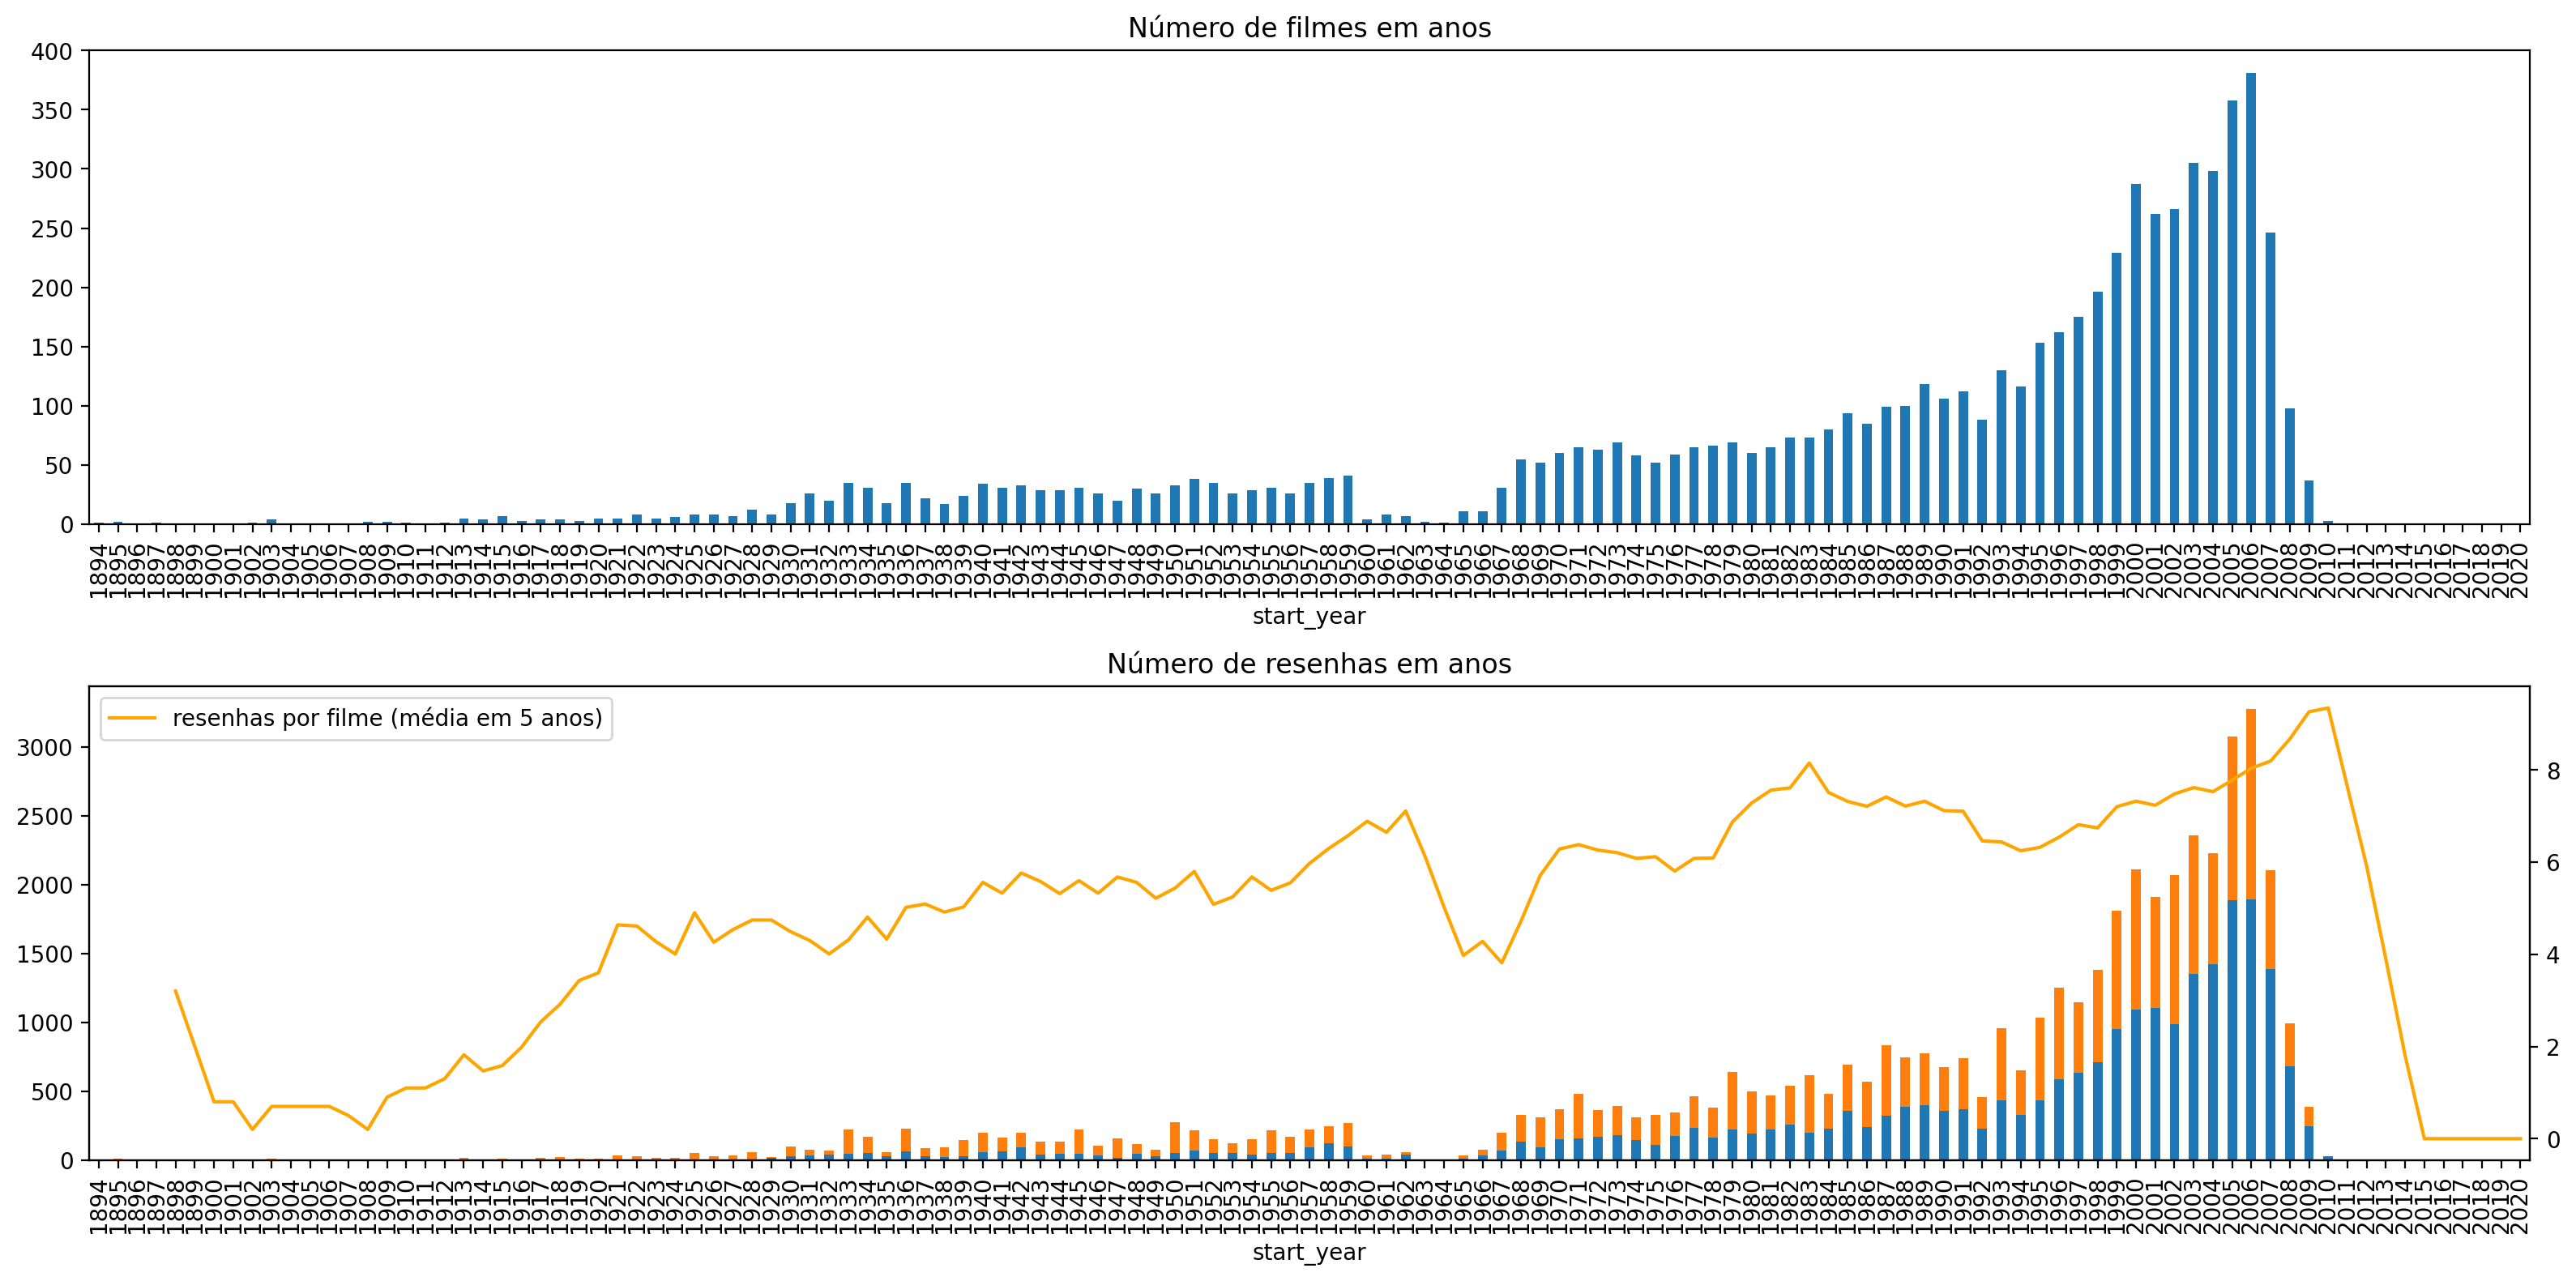

In [54]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

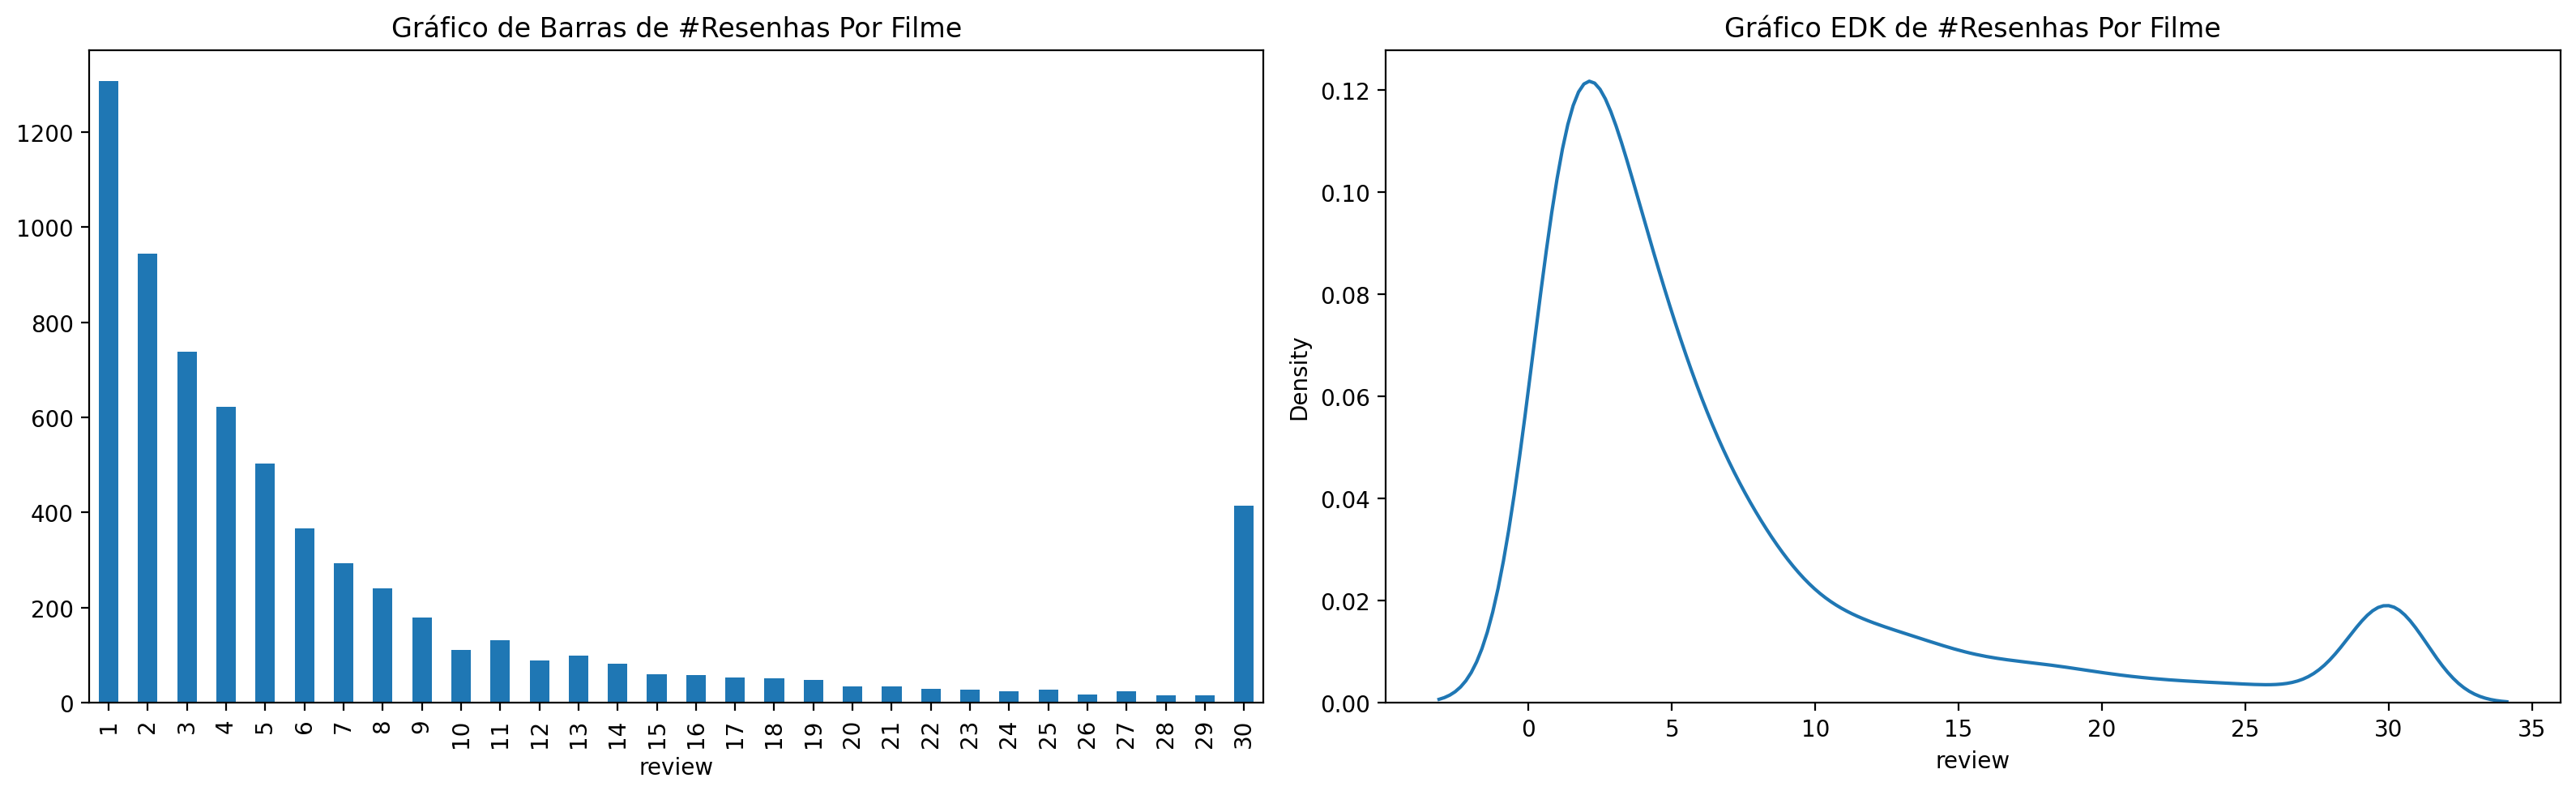

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

Vamos verificar o Equilibrio das classes

In [56]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

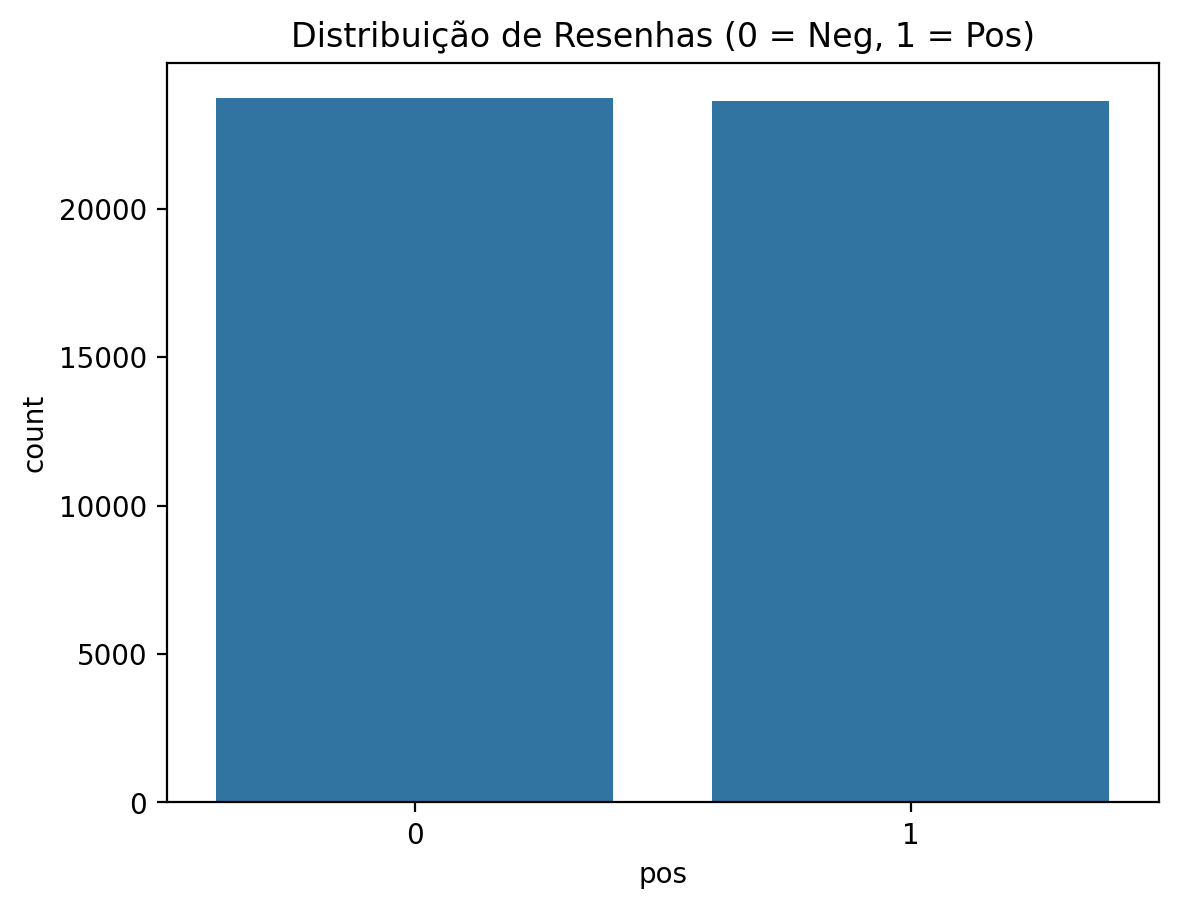

In [57]:
sns.countplot(x='pos', data=df_reviews)
plt.title('Distribuição de Resenhas (0 = Neg, 1 = Pos)')
plt.show()

Os dados estão extremamente equilibrados, praticamente 50% para casa opinião, tornando a métrica F1 Score mais confiável

Vamos analisar a distribuição da classificação nos consjuntos de treino e teste.

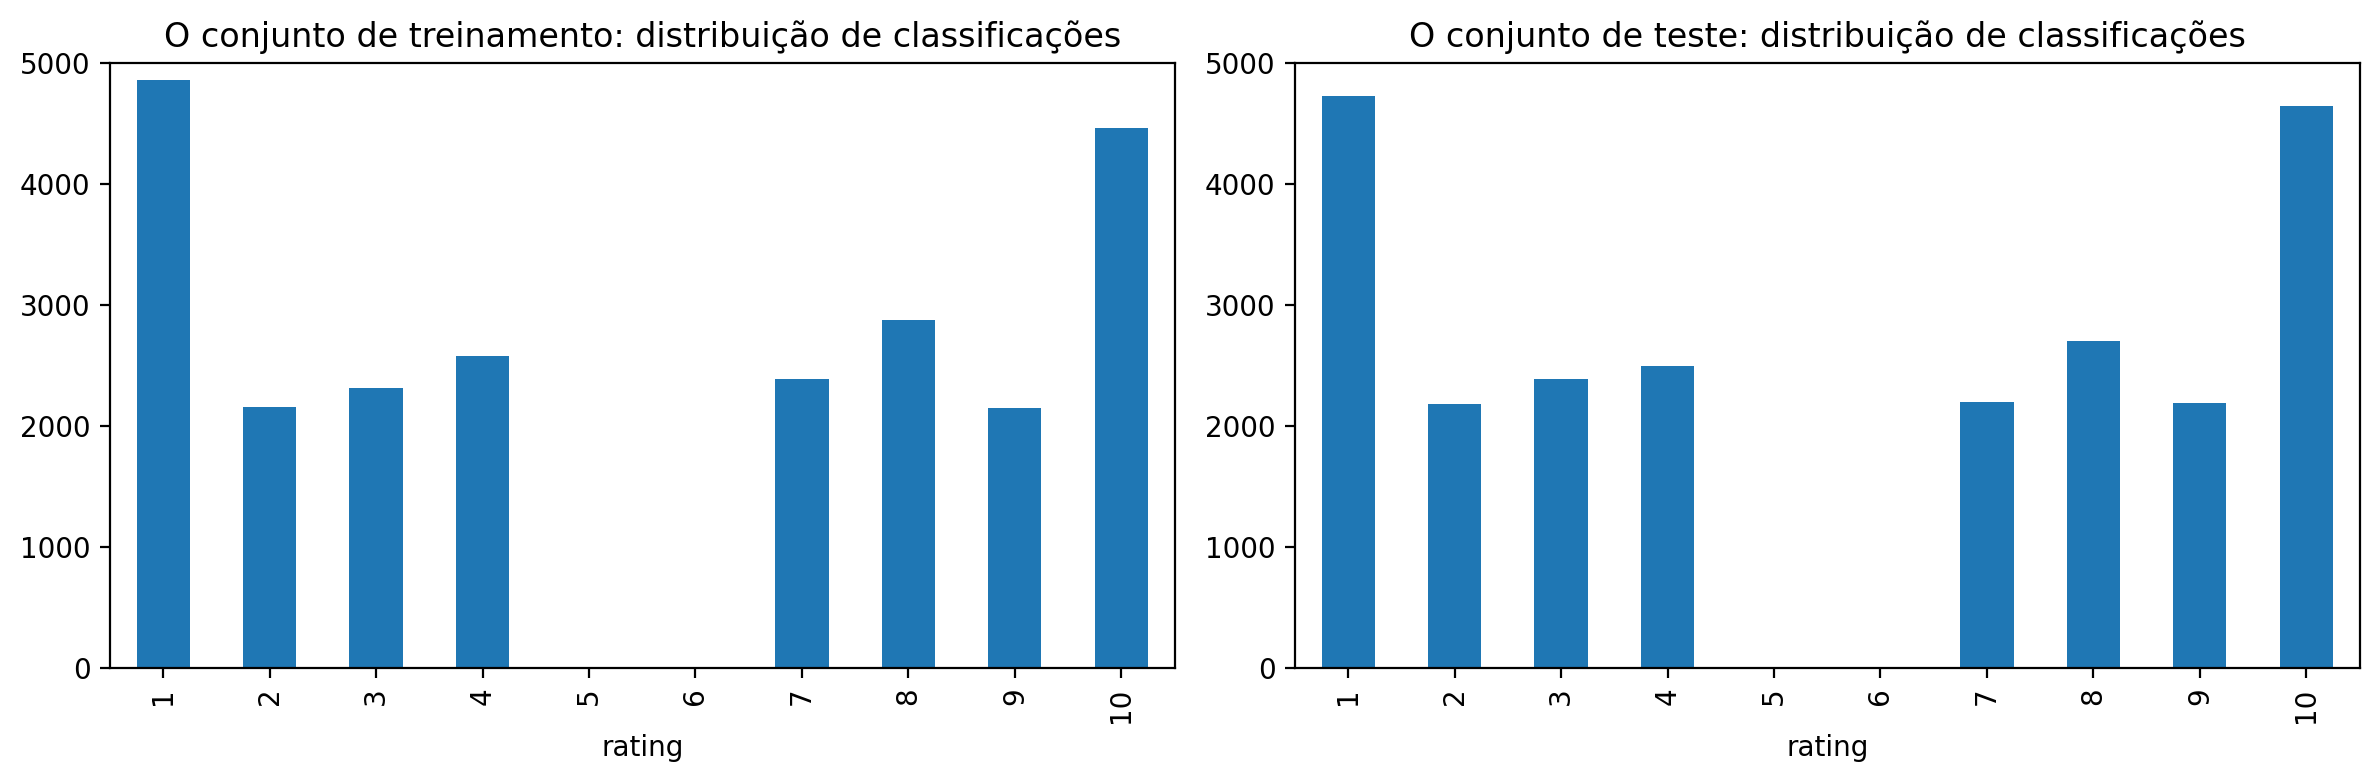

In [58]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/tmp/ipykernel_127766/1483671763.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipykernel_127766/1483671763.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
/tmp/ipykernel_127766/1483671763.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/tmp/ipykernel_127766/1483671763.py:31: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please u

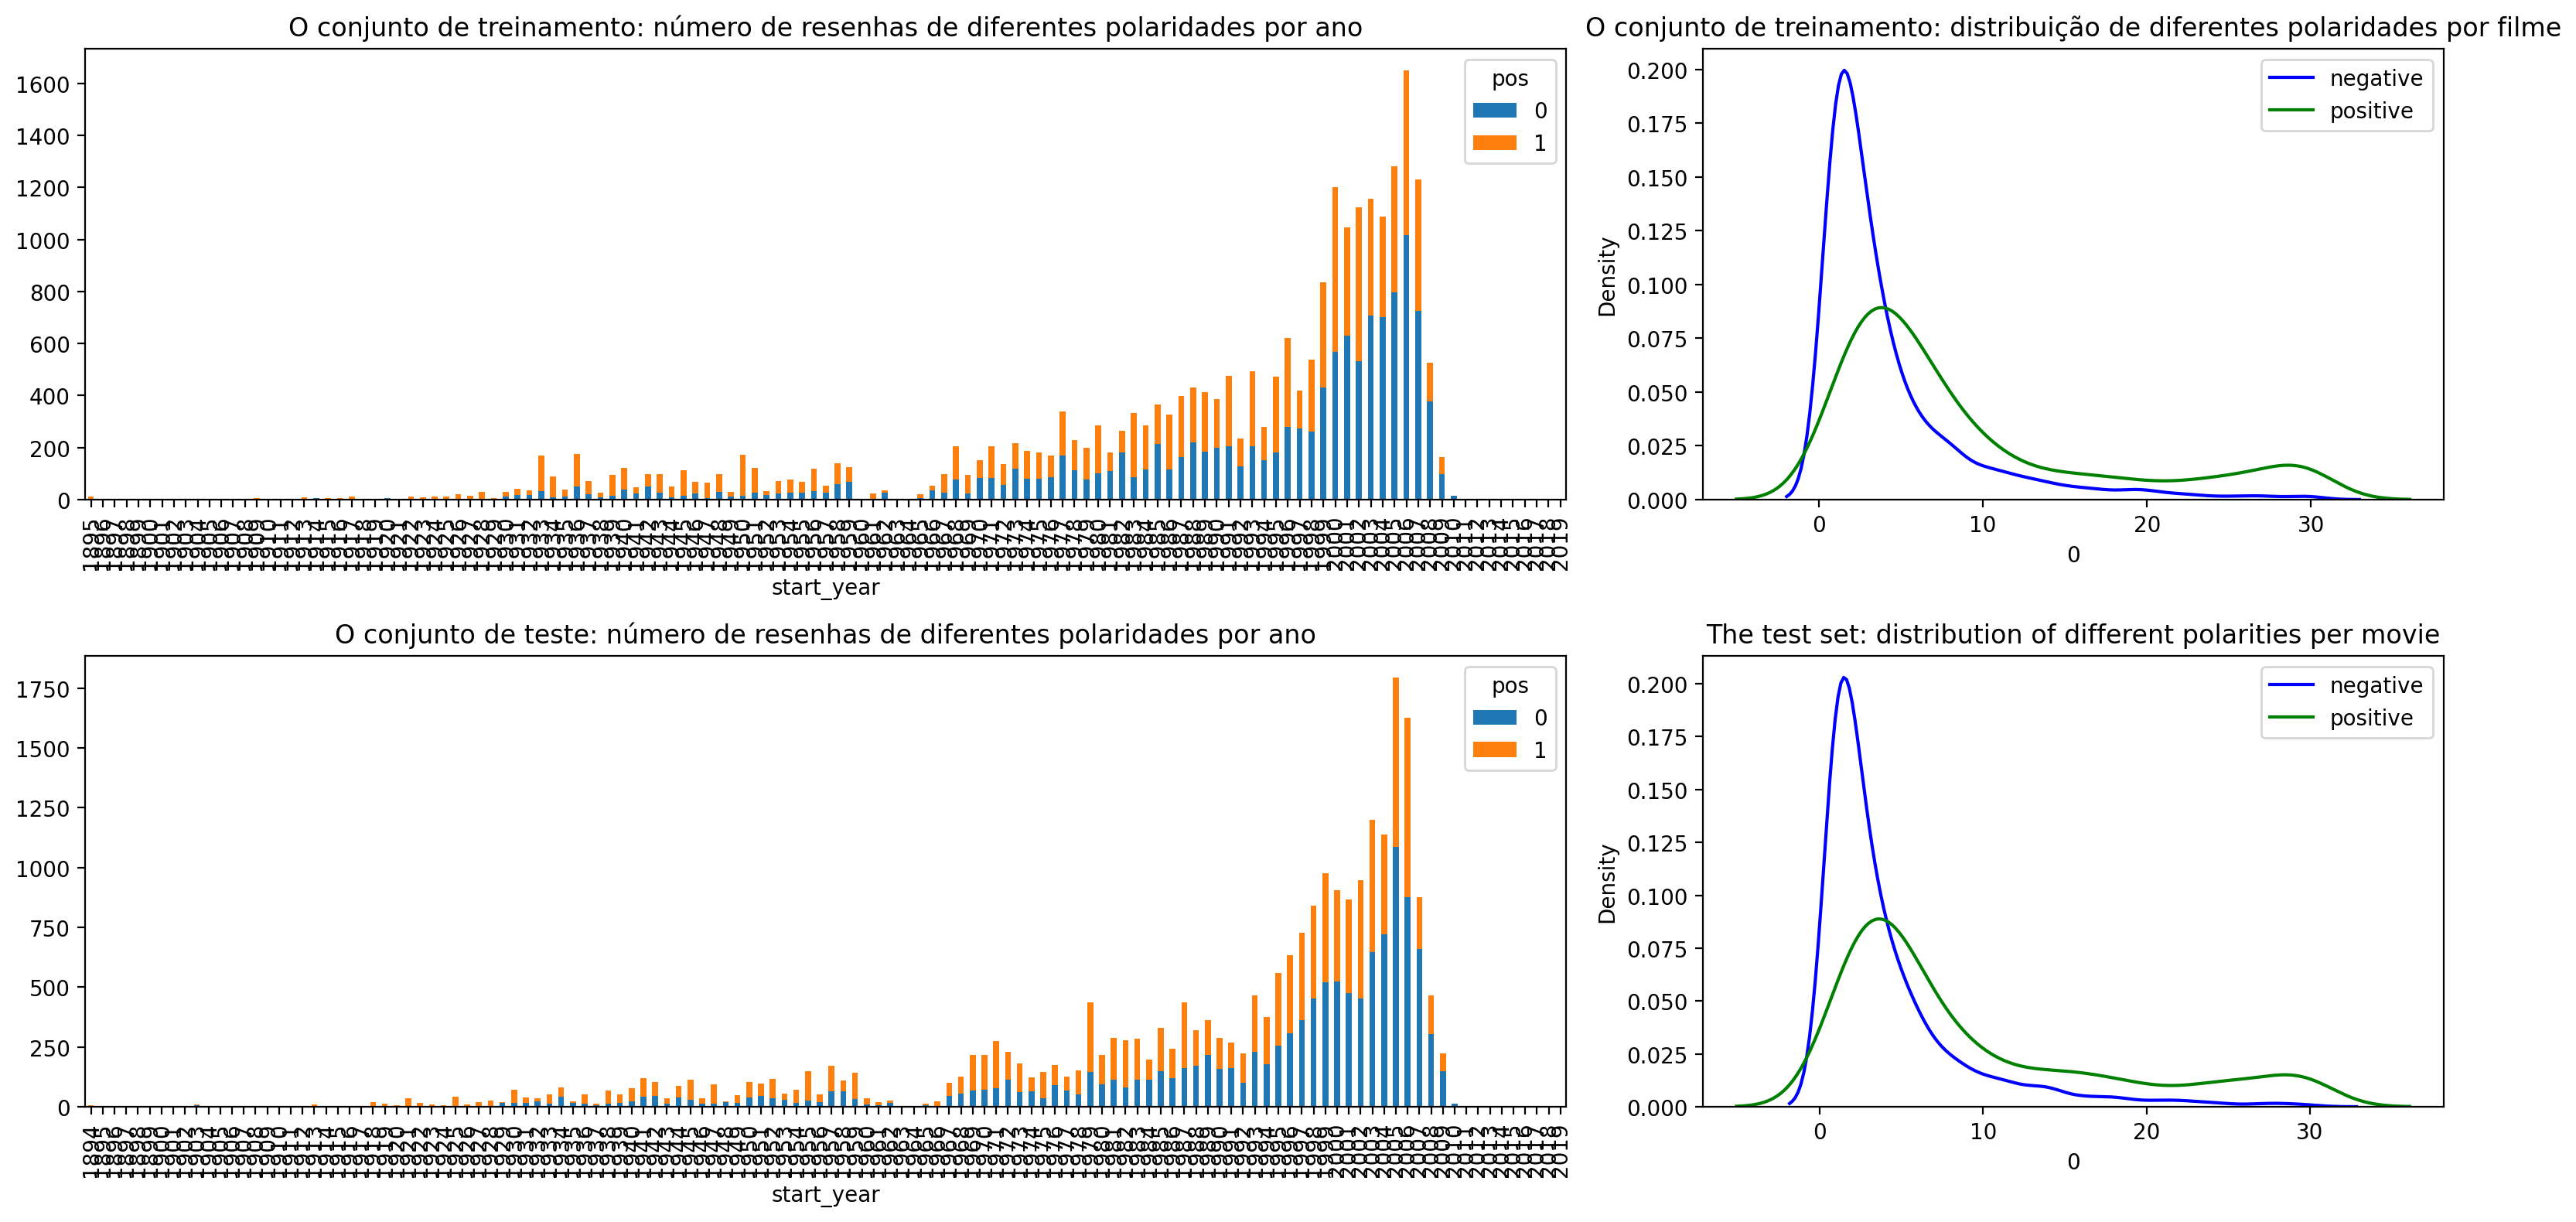

In [59]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [60]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Acurácia', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

# Pré Processamento 

- Tokenização
- Normalização
- Redução de Palavras

A condução do projeto me leva a entender que analisaremos de forma didatica um encremento de cada uma dessas etapas, e possivelmente o melhor desempenho da metrica.

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [44]:
def normalize_text(text):
    # 1. Converte para minúsculas
    text = text.lower()
    # 2. Remove tudo que NÃO for letra (substitui por espaço)
    # O padrão '[^a-zA-Z]' significa: mantenha apenas letras de A a Z
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Remove espaços extras que sobraram
    text = " ".join(text.split())
    return text

In [64]:
df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)

## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [65]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com modelos

### Modelo 0 - Constante

In [ ]:
# 1. Inicializamos o 'tradutor' de palavras para números
# Usamos stop_words='english' para o modelo ignorar palavras inúteis
vectorizer = TfidfVectorizer(stop_words='english')

# 2. Criamos as Features de Treino
# O fit_transform aprende o vocabulário e transforma o texto em números
train_features = vectorizer.fit_transform(df_reviews_train['review_norm'])

# 3. Criamos as Features de Teste
# Usamos apenas transform para que o teste seja traduzido com o vocabulário do treino
test_features = vectorizer.transform(df_reviews_test['review_norm'])

# imprimindo as formas das matrizes de features para verificar se estão corretas
print(train_features.shape)
print(test_features.shape)

(23796, 71365)
(23535, 71365)


          train  test
Acurácia    NaN   NaN
F1          NaN   NaN
APS         0.5   0.5
ROC AUC     0.5   0.5


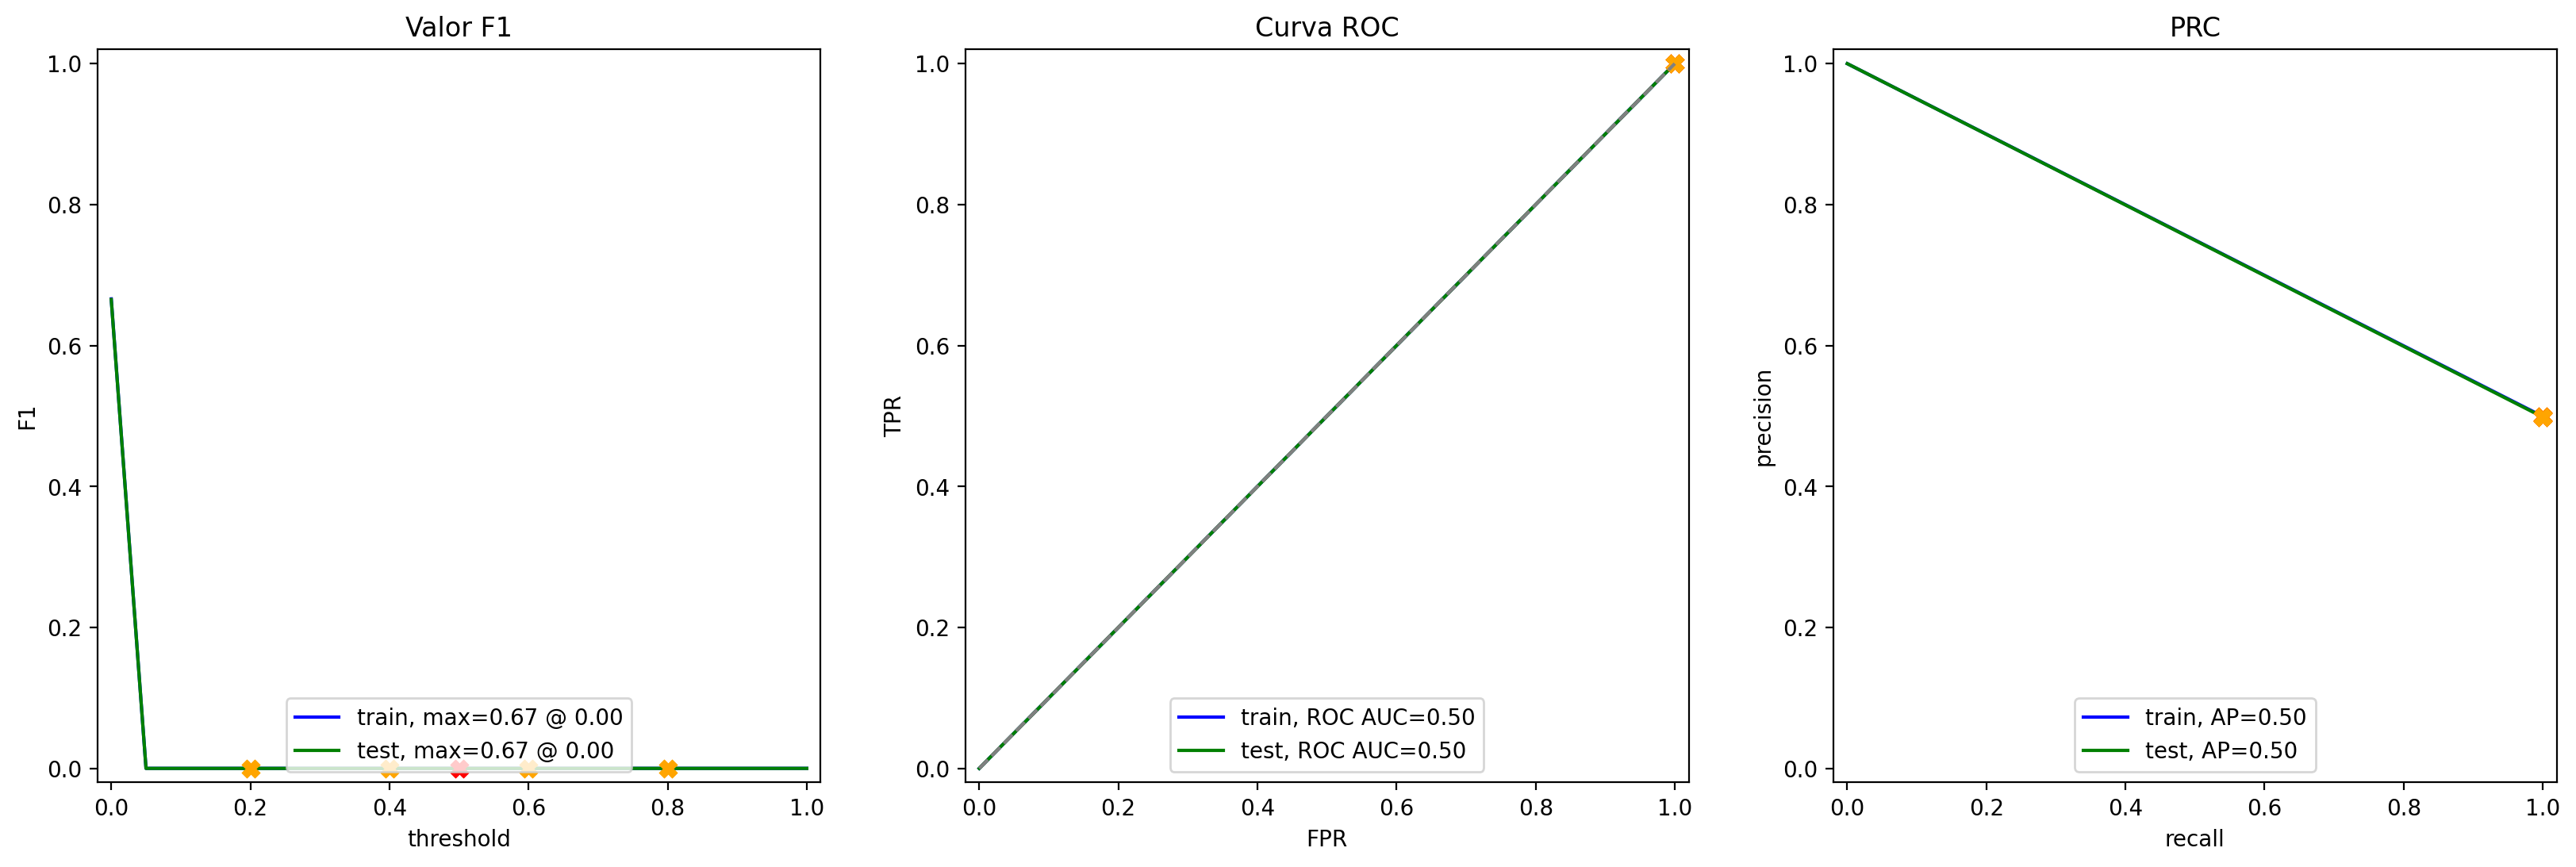

In [67]:

# Criar o modelo que sempre chuta a classe mais frequente
dummy_model = DummyClassifier(strategy='most_frequent')

# Treinar (ele apenas conta qual classe aparece mais)
dummy_model.fit(train_features, train_target)

# Avaliar usando a função que o projeto te deu
evaluate_model(dummy_model, train_features, train_target, test_features, test_target)

### Modelo 1 - NLTK, TF-IDF e Regressão Logistica

NLTK : é uma biblioteca Python usada para ensinar e aplicar técnicas básicas de processamento de linguagem natural, como tokenização, limpeza e análise de texto.


TF - IDF : Ele dá um peso maior para palavras raras e importantes e um peso menor para palavras que aparecem em quase todas as resenhas

In [72]:
import nltk  

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords # Uma lista de palavras gramaticais que aparecem muito, mas não têm "sentimento" (ex: the, is, at, on, by).

Essas bibliotecas importadas acima, me sugerem que eu analise este modelo limpando as palavras inuteis, sem necessariamente fazer a etapa de Lematização.

O NLTK só consegue identificar se uma palavra é "stopwords" se o texto já estiver quebrado em uma lista de palavras individuais.

Nota: O TfidfVectorizer,  faz isso internamente, mas quando usamos o NLTK, geralmente fazemos manualmente primeiro para limpar as palavras. (nltk.word_tokenize(text))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/angelaferrari/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


          train  test
Acurácia    NaN   NaN
F1          NaN   NaN
APS        0.98  0.95
ROC AUC    0.98  0.95


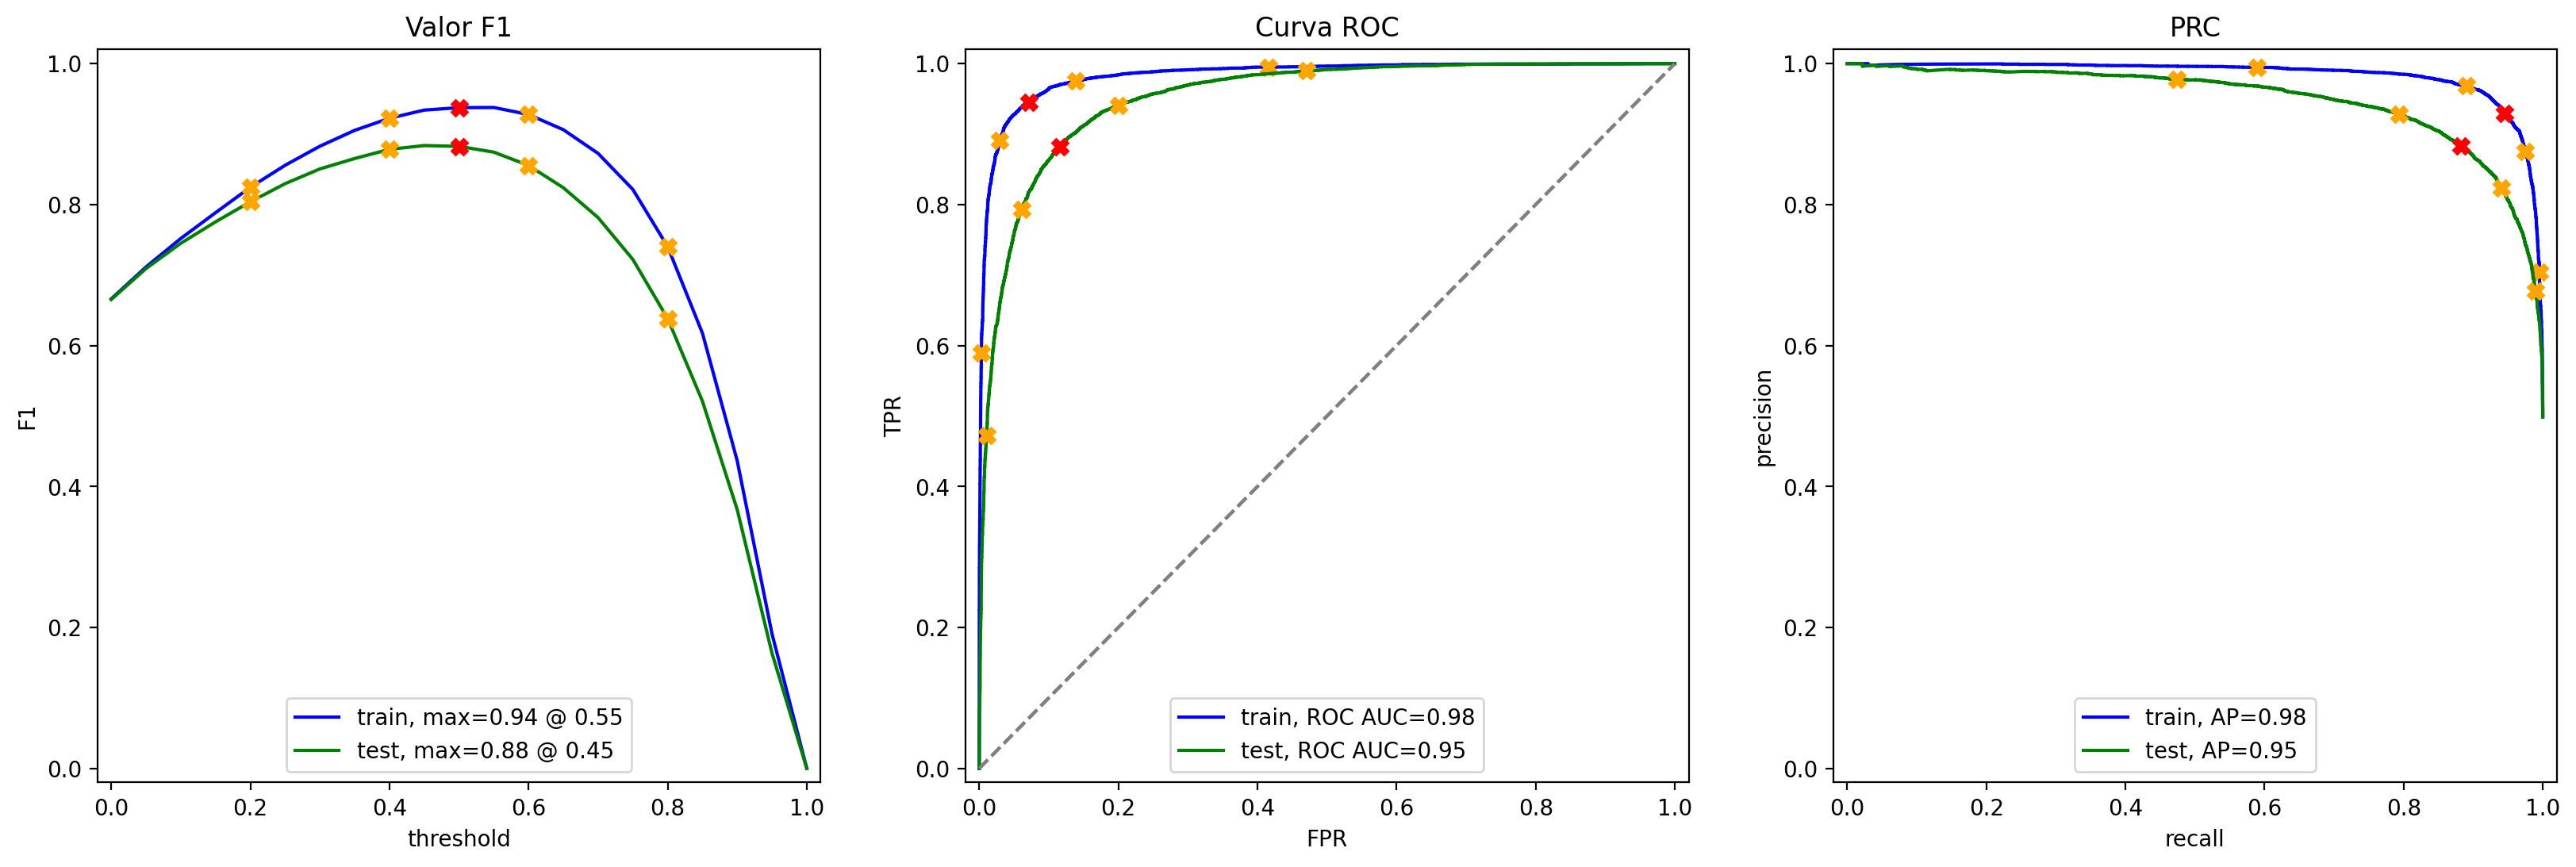

In [74]:
# 1. Garante que as palavras inúteis estão baixadas
nltk.download('stopwords')
stop_words = list(stopwords.words('english'))

# 2. Na hora de criar o vetorizador, você "alimenta" ele com essa lista
vectorizer = TfidfVectorizer(stop_words=stop_words)

# 3. Transforma seu texto normalizado em números
train_features_1 = vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_1 = vectorizer.transform(df_reviews_test['review_norm'])

# 4. Treina a Regressão Logística
model_1 = LogisticRegression(solver='liblinear')
model_1.fit(train_features_1, train_target)

# 5. Avaliar usando a função do projeto
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Modelo 2 - spaCy, TF-IDF e Regressão Linear

In [ ]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner']) # Carrega o modelo spaCy para inglês, desabilitando o parser e o NER

In [76]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    return ' '.join(tokens)

### Modelo 3 - SpaCy, TF-IDF e LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier

###  Modelo 4 - BERT

In [ ]:
import torch
import transformers

In [ ]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [ ]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # texto para IDs de tokens preenchidos com suas máscaras de atenção
    
    # <coloque seu código aqui para criar ids_list e attention_mask_list>
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
    
    # recebendo incorporações em lotes

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <coloque seu código aqui para criar attention_mask_batch
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [ ]:
# Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

In [ ]:
# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## Minhas Resenhas

In [ ]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'Eu simplesmente não gostei, não é meu tipo de filme.',
    'Bem, eu fiquei entediado e dormi no meio do filme.',
    'Eu fiquei realmente fascinado com o filme',    
    'Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.',
    'Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original',
    'O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.',
    'Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crianças não vão gostar disso!',
    'Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após episódio, deste emocionante e inteligente novo drama.'
], columns=['review'])

my_reviews['review_norm'] = # <coloque aqui a mesma lógica de normalização do conjunto de dados principal>

my_reviews

### Modelo 2

In [740]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.14:  eu simplesmente não gostei, não é meu tipo de filme 
0.16:  bem, eu fiquei entediado e dormi no meio do filme 
0.54:  eu fiquei realmente fascinado com o filme
0.11:  os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme
0.31:  eu não esperava que a nova versão fosse tão boa, os escritores realmente se importaram com o material original
0.47:  o filme tem seus prós e contras, mas eu sinto que em geral é um filme decente, eu posso me
0.04:  que tentativa podre de comédia, nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crian
0.82:  lançar na netflix foi uma jogada corajosa, eu realmente aprecio poder assistir episódio após epi


### Modelo 3

In [741]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.40:  eu simplesmente não gostei, não é meu tipo de filme 
0.17:  bem, eu fiquei entediado e dormi no meio do filme 
0.51:  eu fiquei realmente fascinado com o filme
0.31:  os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme
0.31:  eu não esperava que a nova versão fosse tão boa, os escritores realmente se importaram com o material original
0.54:  o filme tem seus prós e contras, mas eu sinto que em geral é um filme decente, eu posso me
0.13:  que tentativa podre de comédia, nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crian
0.86:  lançar na netflix foi uma jogada corajosa, eu realmente aprecio poder assistir episódio após epi


### Modelo 4

In [742]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.58:  eu simplesmente não gostei, não é meu tipo de filme 
0.32:  bem, eu fiquei entediado e dormi no meio do filme 
0.59:  eu fiquei realmente fascinado com o filme
0.43:  os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme
0.58:  eu não esperava que a nova versão fosse tão boa, os escritores realmente se importaram com o material original
0.63:  o filme tem seus prós e contras, mas eu sinto que em geral é um filme decente, eu posso me
0.27:  que tentativa podre de comédia, nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crian
0.85:  lançar na netflix foi uma jogada corajosa, eu realmente aprecio poder assistir episódio após epi


### Modelo 9

In [743]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.21:  eu simplesmente não gostei, não é meu tipo de filme 
0.01:  wbem, eu fiquei entediado e dormi no meio do filme 
0.99:  eu fiquei realmente fascinado com o filme
0.00:  os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme
0.21:  i didn t expect the reboot to be so good  writers really cared about the source material
0.94:  o filme tem seus prós e contras, mas eu sinto que em geral é um filme decente, eu posso me
0.09:  que tentativa podre de comédia, nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crian
0.96:  lançar na netflix foi uma jogada corajosa, eu realmente aprecio poder assistir episódio após epi


## Conclusões

# Checklist

- [x]  O caderno foi aberto
- [x]  Os dados de texto são carregados e pré-processados para vetorização
- [x]  Os dados de texto são transformados em vetores
- [ ]  Os modelos são treinados e testados
- [ ]  O limiar da métrica foi atingido
- [ ]  Todas as células de código estão organizadas na ordem de sua execução
- [ ]  Todas as células de código podem ser executadas sem erros
- [ ]  Há conclusões 